In [1]:
# Add relevant Jupyter notebook extensions 

In [18]:
# You can double-check your Python path like this...
import sys
import os

# Get the project root — go one level up from the current module2 folder
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
sys.path.append('../uuv_mission')
print(sys.path)

['/home/vm/Documents/OxfordGit/3rdYear/B1 Engineering Computation/Scientific Coding/b1-coding-practical-mt25/notebooks', '/home/vm/anaconda3/envs/uuv_mission/lib/python312.zip', '/home/vm/anaconda3/envs/uuv_mission/lib/python3.12', '/home/vm/anaconda3/envs/uuv_mission/lib/python3.12/lib-dynload', '', '/home/vm/anaconda3/envs/uuv_mission/lib/python3.12/site-packages', '../uuv_mission', '/home/vm/Documents/OxfordGit/3rdYear/B1 Engineering Computation/Scientific Coding/b1-coding-practical-mt25', '../uuv_mission', '../uuv_mission']


# Simulate closed-loop
After implementing your control functionality, you can simulate the closed-loop with code that looks something like this...

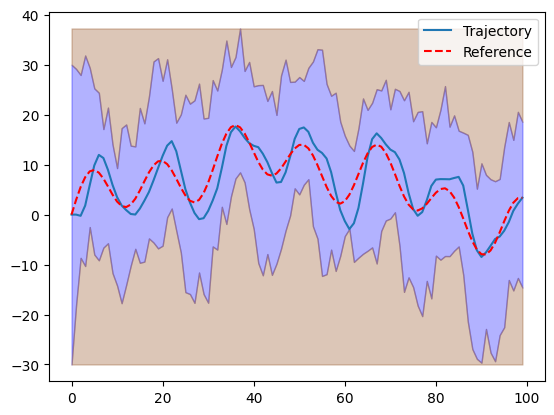

In [58]:
# Import relevant modules

from uuv_mission.control import PDController
from uuv_mission.dynamic import ClosedLoop, Mission, Submarine


sub = Submarine()
# Instantiate your controller (depending on your implementation)
controller = PDController()
closed_loop = ClosedLoop(sub, controller)
mission = Mission.from_csv("../data/mission.csv") # You must implement this method in the Mission class

trajectory = closed_loop.simulate_with_random_disturbances(mission)
trajectory.plot_completed_mission(mission)

To test which proportional gain will ensure the smallest error between the reference and the actual trajectory, we run a simulation over a range of possible values.
Based on the simulation we choose the best gain and plot a completed mission.

The parameter we are trying to minimise is the biggest error between the trajectory and the reference. This is done so that we can ensure that the uuv will not hit the cave.
After running the simulation, we can see that the most appropriate proportional gain is around 0.1 +- 0.01

The most stable PD contoller has a proportional gain of 0.1 with a biggest difference of 11.136257502574503


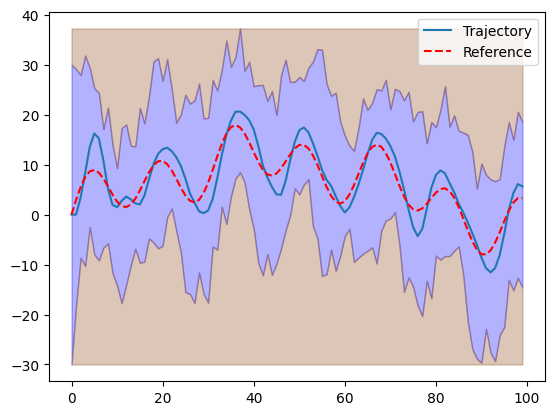

In [77]:
from uuv_mission.control import PDController
from uuv_mission.dynamic import ClosedLoop, Mission, Submarine, Trajectory
import numpy as np


NMB_SIMULATIONS = 10000

def calculate_biggest_difference(trajectory: np.ndarray, reference: np.ndarray) -> float:
    """
    Calculate the biggest difference between the trajectory and the reference trajectory.
    Args:
        trajectory (np.ndarray): The trajectory obtained from the simulation.
        reference (np.ndarray): The reference trajectory from the mission.
    Returns:
        float: The biggest difference between the trajectory and the reference trajectory.
    """

    differences = trajectory - reference
    biggest_difference = differences.max()
    return biggest_difference


sub = Submarine()
mission = Mission.from_csv("../data/mission.csv")
prop_gains = [0.05, 0.08, 0.1, 0.11, 0.12, 0.15, 0.18, 0.2]
min_diff = float('+inf')
final_gain = 0.15 # Gain with the smallest difference
for gain in prop_gains:
    controller = PDController(KP=gain)
    closed_loop = ClosedLoop(sub, controller)
    
    max_curr_diff = float('-inf')
    for _ in range(NMB_SIMULATIONS):
        trajectory = closed_loop.simulate_with_random_disturbances(mission)
        biggest_difference = calculate_biggest_difference(trajectory.position[:, 1], mission.reference)
        max_curr_diff = max(max_curr_diff, biggest_difference)

    if max_curr_diff < min_diff:
        min_diff = max_curr_diff
        final_gain = gain

print(f"The most stable PD contoller has a proportional gain of {final_gain} with a biggest difference of {min_diff}")
controller = PDController(KP=final_gain)
trajectory.plot_completed_mission(mission)